In [1]:
# Import libraries
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt # plotting
import seaborn as sns

# Show plots inline
%matplotlib inline 

In [2]:
# Load dataset
df = pd.read_csv('201902-fordgobike-tripdata.csv') 

# Show first rows
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [3]:
# Shape
df.shape



(183412, 16)

In [4]:
# Info
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [5]:
# Describe
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [6]:
# Check missing values
df.isna().sum()



duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## Initial Data Exploration

The dataset contains 183,412 records and 16 columns, including trip details, station information, and user demographics.

### Data Quality

- Missing values exist in:
  - `member_birth_year` and `member_gender` (8265 each)
  - station-related columns (197 values)
- No duplicate rows were found.

### Observations

- Most trips are short, but there are extreme outliers in duration.
- Time columns are stored as objects and need conversion to datetime.

### Next Step

Data cleaning will address missing values, outliers, and data types.

In [8]:
# Check for duplicates
df_clean = df.copy() # Create a copy of the original dataset to work with
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'])# Convert 'start_time' to datetime format
df_clean['end_time'] = pd.to_datetime(df_clean['end_time']) # Convert 'end_time' to datetime format

df_clean['start_hour'] = df_clean['start_time'].dt.hour # Extract the hour from 'start_time' and create a new column 'start_hour'
df_clean['start_day'] = df_clean['start_time'].dt.day_name() # Extract the day name from 'start_time' and create a new column 'start_day'

df_clean['age'] = 2019 - df_clean['member_birth_year']# Calculate age by subtracting 'member_birth_year' from 2019 and create a new column 'age'

In [9]:
df_clean = df_clean[df_clean['duration_sec'] < 5000] # Filter the dataset to include only rows where 'duration_sec' is less than 5000, removing outliers with excessively long durations.
df_clean = df_clean[(df_clean['age'] > 0) & (df_clean['age'] < 100)]#  Filter the dataset to include only rows where 'age' is greater than 0 and less than 100, removing unrealistic ages.


In [10]:
df_clean = df_clean.dropna(subset=['member_gender', 'member_birth_year']) # Drop rows

In [11]:
df_clean.shape # Check the shape of the cleaned dataset after removing duplicates and outliers.


(174189, 19)

In [12]:
df_clean.head() # Show the first rows of the cleaned dataset to verify the changes made during the cleaning process.

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_hour,start_day,age
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,23,Thursday,45.0
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,23,Thursday,60.0
6,1147,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No,23,Thursday,36.0
7,1615,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No,23,Thursday,30.0
8,1570,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No,23,Thursday,31.0


## Data Cleaning Summary
A copy of the dataset was created to preserve the original data.
Datetime conversion was applied to time columns.
New features were created (hour, day, age).
Unrealistic values in duration and age were removed.
Missing values in gender and birth year were dropped.
The dataset was reduced from 183,412 to 174,189 records.

## Visualization

## Univariate Exploration

In this section, I explore individual variables to understand their distributions.  
The main questions are: How are trip durations distributed? What type of users use the system most?

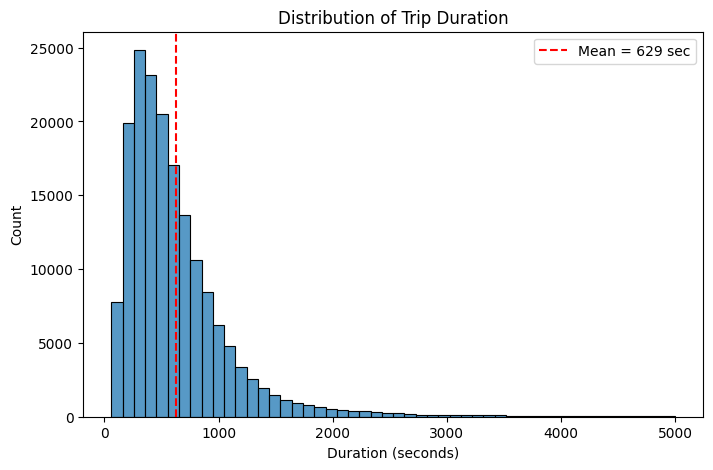

In [13]:
 # Univariate 1: Distribution of trip duration  
plt.figure(figsize=(8,5))
sns.histplot(df_clean['duration_sec'], bins=50)

mean_duration = df_clean['duration_sec'].mean()
plt.axvline(mean_duration, color='red', linestyle='--', label=f'Mean = {mean_duration:.0f} sec')

plt.title('Distribution of Trip Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.legend()

### Question
What is the distribution of trip duration?

### Visualization
(A histogram showing the distribution of trip duration was created.)

### Observation
- The distribution of trip duration is right-skewed.
- Most trips are concentrated between 200 and 800 seconds.
- There are fewer trips with long durations, forming a long tail to the right.
- This suggests that most users take short trips, with occasional longer rides.

Text(0, 0.5, 'Count')

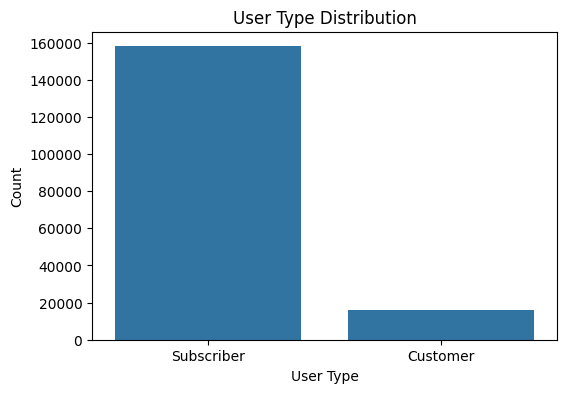

In [14]:
# Univariate 2: Count Plot User type distribution 
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='user_type')

plt.title('User Type Distribution')
plt.xlabel('User Type')
plt.ylabel('Count')

### Question
What is the distribution of user types?

### Visualization
(A count plot showing the distribution of user types was created.)

### Observation
- The majority of users are Subscribers.
- Customers represent a much smaller portion of the dataset.
- This suggests that the system is mainly used by regular, subscribed users.
- Casual usage by non-subscribers is relatively low.

## Bivariate Exploration

In this section, I explore relationships between pairs of variables.  
The main questions are: How does trip duration vary by user type, age, and day of week?

Text(0, 0.5, 'Duration (seconds)')

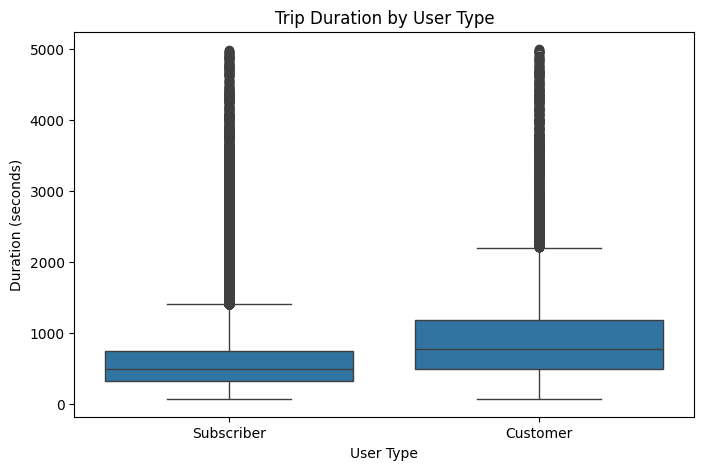

In [15]:
# Bivariate 1: Box Plot of Trip Duration by User Type
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='user_type', y='duration_sec')

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration (seconds)')

### Question
How does trip duration vary by user type?

### Visualization
(A box plot comparing trip duration between Subscribers and Customers was created.)

### Observation
- Customers tend to have longer trip durations compared to Subscribers.
- The median trip duration for Customers is higher than for Subscribers.
- Subscribers generally take shorter and more consistent trips.
- There are several outliers in both groups, indicating some unusually long trips.
- This suggests that Customers may use the service for leisure, while Subscribers use it for regular commuting.

Text(0, 0.5, 'Duration (seconds)')

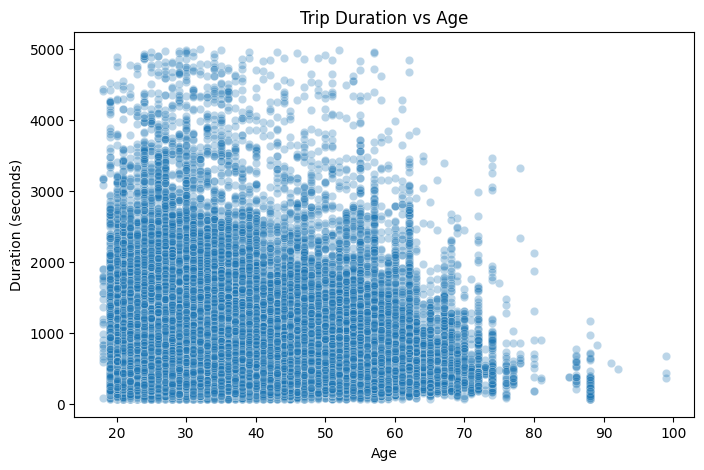

In [16]:
# Bivariate 2: Scatter Plot of Trip Duration vs Age
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='age', y='duration_sec', alpha=0.3)

plt.title('Trip Duration vs Age')
plt.xlabel('Age')
plt.ylabel('Duration (seconds)')

### Question
How does age affect trip duration?

### Visualization
(A scatter plot showing the relationship between age and trip duration was created.)

### Observation
- Most users are between 20 and 40 years old.
- There is a slight negative relationship between age and trip duration.
- Younger users tend to have longer trips, while older users generally take shorter trips.
- The data shows a wide spread, indicating that age is not a strong predictor of trip duration.
- Some outliers exist with very long durations, mostly among younger users.

Text(0, 0.5, 'Count')

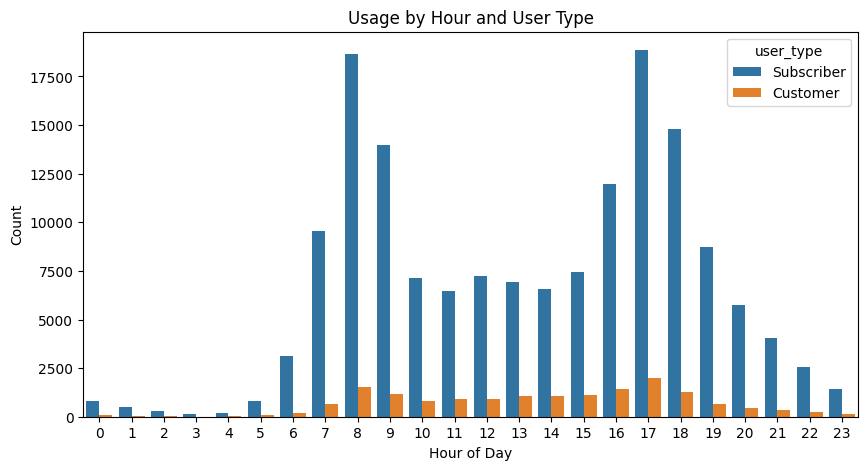

In [17]:
# Bivariate 3: Count Plot of Trips by Hour and User Type
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='start_hour', hue='user_type')

plt.title('Usage by Hour and User Type')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

### Question
How does usage vary by hour of the day and user type?

### Visualization
(A count plot showing usage by hour and user type was created.)

### Observation
- Subscribers show clear peaks in usage around 8 AM and 5–6 PM.
- These peaks correspond to typical commuting hours.
- Customers have much lower usage and do not show strong patterns across the day.
- Customer usage is more evenly distributed and less predictable.

### Insight
- Subscribers primarily use the service for daily commuting.
- Customers likely use the service for leisure or occasional trips.
- This indicates that the bike-sharing system is heavily used as a transportation tool rather than just for recreational purposes.

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

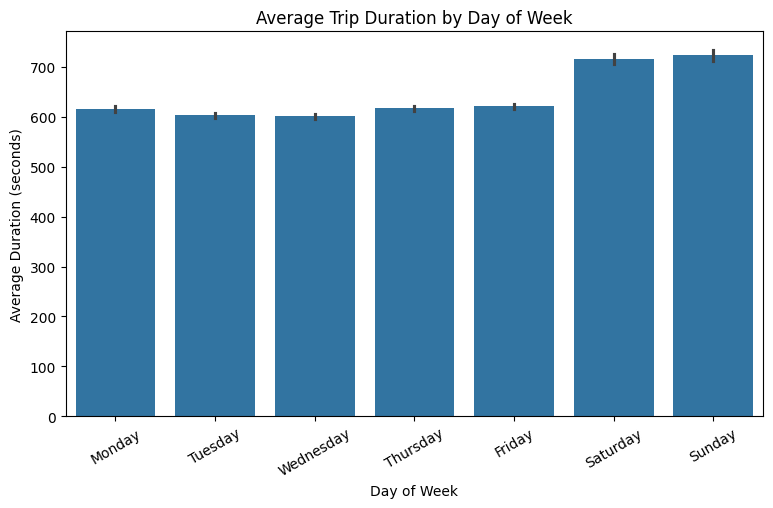

In [18]:
# Bivariate 4: Bar Plot of Average Trip Duration by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(9,5))
sns.barplot(data=df_clean, x='start_day', y='duration_sec', order=day_order, color='tab:blue')

plt.title('Average Trip Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=30)

### Question
How does the average trip duration vary by day of the week?

### Visualization
(A bar chart showing the average trip duration for each day of the week was created.)

### Observation
- Trip durations are fairly similar across weekdays.
- There is a noticeable increase in trip duration during weekends (Saturday and Sunday).
- This suggests that users tend to take longer trips during weekends, likely for leisure rather than commuting.

## Multivariate Exploration

In this section, I explore relationships involving three or more variables.  
The main question is whether user type changes the relationship between time, age, and trip duration.

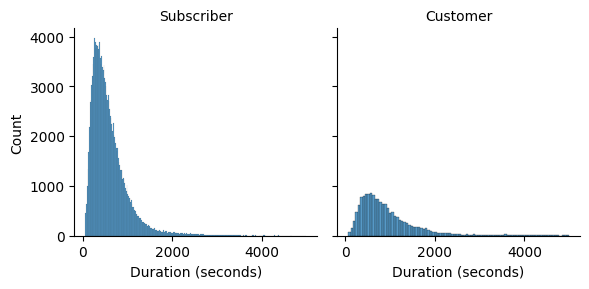

In [19]:
# Multivariate 1: Facet Grid of Trip Duration by User Type
g = sns.FacetGrid(data=df_clean, col='user_type')
g.map(sns.histplot, 'duration_sec')

g.set_titles("{col_name}")
g.set_axis_labels("Duration (seconds)", "Count")

### Question
How does the distribution of trip duration differ between user types?

### Visualization
(A faceted histogram comparing trip duration for Subscribers and Customers was created.)

### Observation
- Subscriber trips are heavily concentrated at shorter durations.
- Customer trips have a wider distribution and tend to be longer.
- Both distributions are right-skewed, but Customers show more variability.

### Insight
- Subscribers tend to use the service for short, routine trips such as commuting.
- Customers are more likely to take longer and more varied trips, suggesting leisure usage.
- This highlights a clear behavioral difference between the two user groups.

Text(0.5, 1.0, 'Correlation Matrix')

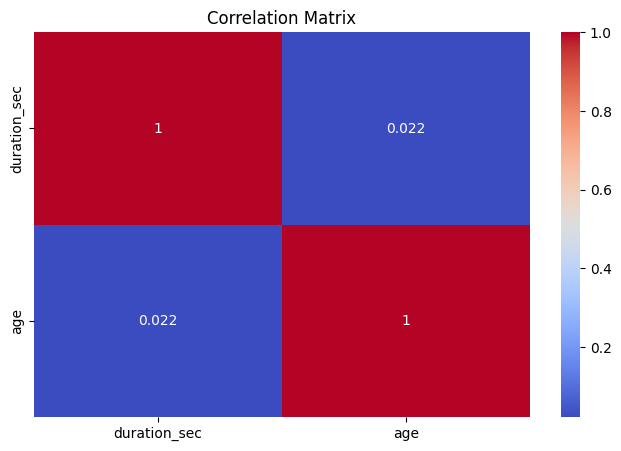

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(df_clean[['duration_sec','age']].corr(),
            annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')

### Question
Is there a relationship between age and trip duration?

### Visualization
(A heatmap showing the correlation between age and trip duration was created.)

### Observation
- The correlation coefficient between age and trip duration is approximately 0.02.
- This indicates almost no linear relationship between the two variables.

### Insight
- Age does not significantly influence how long a trip lasts.
- Other factors, such as user type, are more important in determining trip duration.

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '0-9'),
  Text(1, 0, '10-19'),
  Text(2, 0, '20-29'),
  Text(3, 0, '30-39'),
  Text(4, 0, '40-49'),
  Text(5, 0, '50-59'),
  Text(6, 0, '60-69'),
  Text(7, 0, '70-79'),
  Text(8, 0, '80-89')])

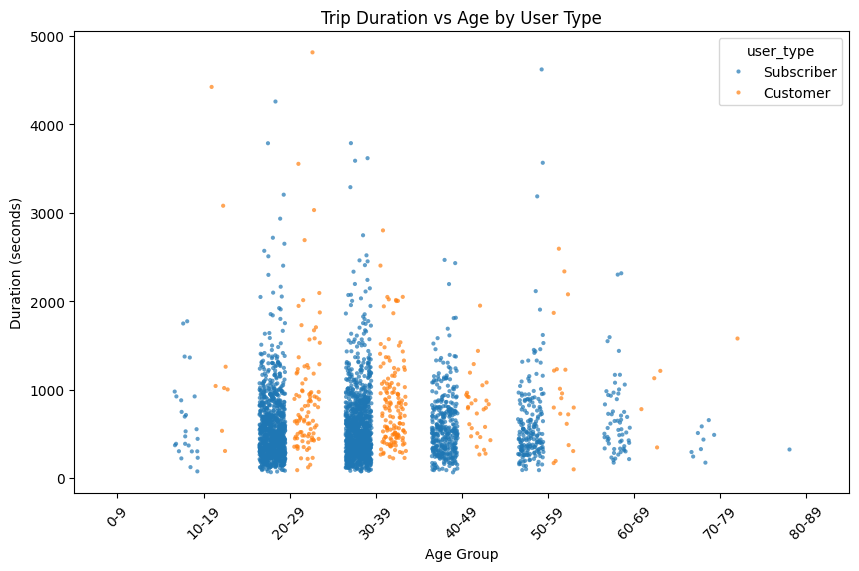

In [21]:
plot_df = df_clean.sample(3000, random_state=1)

bins = range(0, int(plot_df['age'].max()) + 10, 10)
labels = [f"{i}-{i+9}" for i in bins[:-1]]

plot_df['age_bin'] = pd.cut(plot_df['age'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=plot_df,
    x='age_bin',
    y='duration_sec',
    hue='user_type',
    dodge=True,
    jitter=0.3,
    size=3,
    alpha=0.7
)

plt.title('Trip Duration vs Age by User Type')
plt.xlabel('Age Group')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)

### Question
How does the relationship between age and trip duration differ by user type?

### Visualization
(A strip plot of trip duration across age groups, colored by user type, was created.)

### Observation
- Customers tend to take longer trips across most age groups.
- Subscribers generally take shorter and more consistent trips.
- There is no strong relationship between age and trip duration.
- User type has a stronger influence on trip duration than age.

### Insight
- Trip duration is influenced more by user type than by age.
- Subscribers likely use the service for routine, short trips such as commuting.
- Customers appear to use the service more for longer, flexible, or leisure trips.

Text(0.5, 1.02, 'Plot Matrix of Duration, Age, and Start Hour')

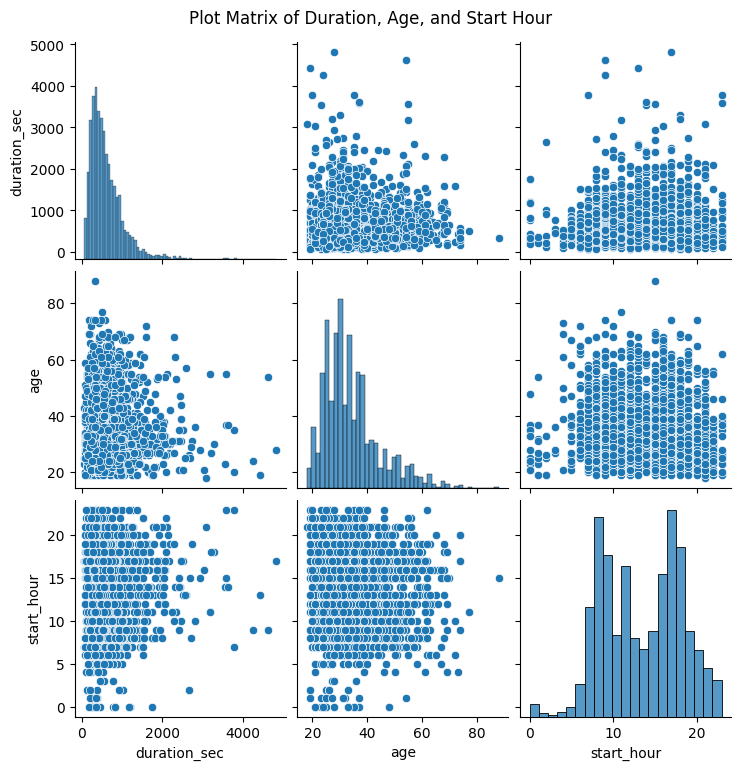

In [22]:
sample_df = df_clean[['duration_sec', 'age', 'start_hour']].sample(3000, random_state=1)

sns.pairplot(sample_df)
plt.suptitle('Plot Matrix of Duration, Age, and Start Hour', y=1.02)

### Question
What are the relationships between duration, age, and start hour?

### Visualization
(A plot matrix showing pairwise relationships between duration, age, and start hour was created.)

### Observation
- Trip duration is highly right-skewed.
- Age shows no strong correlation with duration.
- Start hour shows clustering during daytime hours.
- No strong linear relationships are observed between the variables.

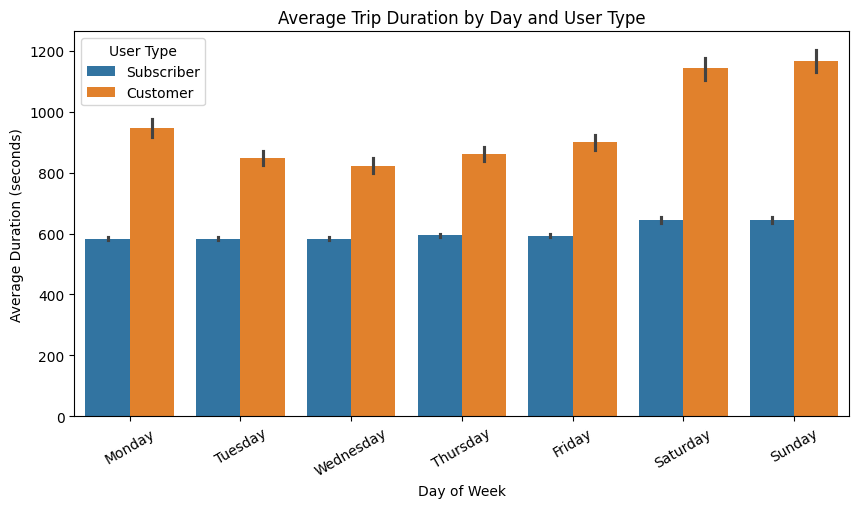

In [23]:
# Bivariate 5: Bar Plot of Average Trip Duration by Day of Week and User Type
plt.figure(figsize=(10,5))
sns.barplot(data=df_clean, x='start_day', y='duration_sec', hue='user_type', order=day_order)

plt.title('Average Trip Duration by Day and User Type')
plt.xlabel('Day of Week')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=30)
plt.legend(title='User Type')

### Question
How does trip duration vary by both user type and day of the week?

### Visualization
(A clustered bar chart comparing average trip duration by day of the week and user type was created.)

### Observation
- Customers consistently have longer trip durations than Subscribers across all days.
- Both user types show slightly longer trips during weekends.
- Subscribers maintain relatively stable trip durations throughout the week.
- This suggests that Customers use the service more for leisure, while Subscribers use it for regular transportation.

## Final Summary of Findings

- The majority of users are Subscribers, indicating that the system is primarily used by regular users.
- Trip duration is highly right-skewed, with most trips being short and only a few long trips.
- Customers tend to have longer trip durations compared to Subscribers.
- Subscribers show strong usage patterns during commuting hours (morning and evening peaks).
- Customers have more evenly distributed usage throughout the day.
- Younger users tend to have slightly longer trips, but age is not a strong factor in determining trip duration.
- There is almost no correlation between age and trip duration, suggesting other variables are more influential.
- Overall, the data suggests that Subscribers use the system for daily transportation, while Customers use it more for leisure.